In [1]:
from tools import MeshGenerator, FrameField, NACA_airfoil, StreamlineGenerator, StreamlineGenerator_v2
from tools import QuadMeshGenerator
from tools import MeshCheck

from gmsh import merge
import numpy as np
import torch
from torch_geometric.data import Data
from scipy.interpolate import splprep, splev


from torch_geometric.data import Data
# from tools.streamline_merging import StreamlineMerging
from tools.streamline_intersection_splitter import StreamlineIntersectionSplitter
from tools.streamlines_to_quad_faces import QuadFaceGenerator


In [2]:
from tools.plotting_tools import *

In [3]:
import matplotlib.pyplot as plt
def plt_faces(mesh):
    plt.figure()
    nodes = mesh.x
    faces = mesh.faces
    streamline_mapping = mesh.edge_to_streamline

    num_edges_each_faces = faces.size(0)
    
    for i,face in enumerate(faces.T):
        streamlines = []
        rand_color = np.random.rand(3,)
        for j in range(num_edges_each_faces):
            edge_idx1 =j
            edge_idx2 =(j+1)%num_edges_each_faces

            edge = (face[edge_idx1].item(),face[edge_idx2].item())
            streamline = streamline_mapping[edge]
            streamlines.append(streamline)
            
        surface = np.vstack(streamlines)
        plt.fill(surface[:,0],surface[:,1],color = rand_color)


            
        

In [4]:


class StreamlineMerging:

    def __init__(self, mesh: Data, verbose: bool = True):

        self.verbose = verbose
        self.Streamlines,self.Singularities = self.prepare_streamlines(mesh)
        self.new_streamlines                = self.merge_streamlines(self.Streamlines)

    def prepare_streamlines(self, mesh: Data):

        if self.verbose == True:
            print("\n function pre_processing \n")

        tol = 10e-3
        Singularities = {}
        Streamlines = {}

        mask_c0_nodes               = mesh.x[:, 2] == 0
        c0_nodes                    = mesh.x[mask_c0_nodes, 0:2]
        singularity_coords          = torch.tensor([mesh.singularities_coords[sing] for sing in mesh.singularities_coords])
        streamline_termination_nodes = torch.cat((c0_nodes, singularity_coords), 0)

        streamlines = mesh.streamlines

        for j in range(streamline_termination_nodes.size(0)):
            Singularities[j] = {"streamline_in": [], "streamline_out": [], "coords": streamline_termination_nodes[j], "is_boundary": j >= len(singularity_coords)}

        for i in range(len(streamlines)):
            streamline = torch.from_numpy(streamlines[i])
            Streamlines[i] = {"singularity_in": None, "singularity_out": None, "coords": streamline, "is_boundary": False,"angle_in":None, "angle_out": None }

        for i in range(len(streamlines)):
            streamline = torch.from_numpy(streamlines[i])
            start = streamline[0]
            end = streamline[-1]
            
            potential_cut = [] # store the indices where a streamline has a short distance to a termination node, cut it at the first index
            
            start_is_boundary = False
            end_is_boundary = False

            for j in range(streamline_termination_nodes.size(0)):

                termination_node    = streamline_termination_nodes[j, :]
                distance_start      = torch.linalg.norm(start - termination_node)
                distance_end        = torch.linalg.norm(end - termination_node)


                if distance_start < tol:

                    start_is_boundary = Singularities[j]["is_boundary"]
                    Singularities[j]["streamline_out"].append(i)
                    Streamlines[i]["singularity_out"] = j
                    
                    dx = streamline[1,0] - streamline[0,0]
                    dy = streamline[1,1] - streamline[0,1]
                    
                    Streamlines[i]["angle_out"] = torch.atan2(dy,dx)

                elif distance_end < tol:

                    end_is_boundary = Singularities[j]["is_boundary"]
                    Singularities[j]["streamline_in"].append(i)
                    Streamlines[i]["singularity_in"] = j
                    
                    dx = streamline[-1,0] - streamline[-2,0]
                    dy = streamline[-1,1] - streamline[-2,1]
                    
                    Streamlines[i]["angle_in"] = torch.atan2(dy,dx)
            if start_is_boundary and end_is_boundary:
                Streamlines[i]["is_boundary"] = True

        return Streamlines,Singularities

    def find_missed_streamline_endpoints(self, Streamlines, Singularities):
    
        for key in Singularities.keys():
            s_in = Singularities[key]["streamline_in"]

            if not s_in:
                continue

            s_out = Singularities[key]["streamline_out"]
            if not s_out:
                continue

            # Für jede eingehende Stromlinie
            for streamline_in in s_in:
                angle_in = Streamlines[streamline_in]['angle_in']

                # Finde beste passende ausgehende Stromlinie
                best_angle_diff = torch.pi  # Maximaler Winkelunterschied
                best_match_id = None

                for streamline_out in s_out:
                    angle_out = Streamlines[streamline_out]['angle_out']

                    # Normalisiere Winkeldifferenz auf [-π, π]
                    angle_diff = angle_in - angle_out
                    angle_diff = torch.atan2(torch.sin(angle_diff), torch.cos(angle_diff))
                    angle_diff_abs = torch.abs(angle_diff)

                    # Prüfe ob dies ein Gegenstück ist (ungefähr 180° Unterschied)
                    if torch.abs(angle_diff_abs - torch.pi) < best_angle_diff:
                        best_angle_diff = torch.abs(angle_diff_abs - torch.pi)
                        best_match_id = streamline_out

                        if self.verbose:
                            print(f'Found potential match: streamline_in={streamline_in}, '
                                  f'streamline_out={best_match_id}, angle_diff={angle_diff_abs:.3f}')

                # Wenn eine passende Stromlinie gefunden wurde
                if best_match_id is not None and best_angle_diff < torch.pi/4:  # Toleranz von 45°
                    # Die ausgehende Stromlinie sollte an der anderen Singularität enden
                    target_sing_id = Streamlines[streamline_in]["singularity_out"]

                    # Überprüfe ob diese Stromlinie noch kein Ende hat
                    if Streamlines[best_match_id]["singularity_in"] is None and target_sing_id is not None:
                        target_singularity = Singularities[target_sing_id]['coords']
                        streamline_coords = Streamlines[best_match_id]["coords"]

                        # Berechne Distanz aller Punkte zur Ziel-Singularität
                        distances = torch.linalg.norm(
                            streamline_coords - target_singularity.unsqueeze(0), 
                            dim=1
                        )

                        # Finde nächsten Punkt
                        min_idx = torch.argmin(distances)
                        min_distance = distances[min_idx]

                        if self.verbose:
                            print(f'Streamline {best_match_id} passes singularity {target_sing_id} '
                                  f'at distance {min_distance:.6f} at index {min_idx}')

                        # Schneide nur wenn Distanz klein genug ist
                        if min_distance < 0.1:  # Toleranz anpassen
                            # Schneide Stromlinie am nächsten Punkt
                            cut_streamline = streamline_coords[:min_idx+1, :]

                            # Update Stromlinie
                            Streamlines[best_match_id]['coords'] = cut_streamline
                            Streamlines[best_match_id]["singularity_in"] = target_sing_id

                            # Update Singularität
                            if best_match_id not in Singularities[target_sing_id]["streamline_in"]:
                                Singularities[target_sing_id]["streamline_in"].append(best_match_id)

                            # Berechne neuen Eingangswinkel
                            if len(cut_streamline) > 1:
                                dx = cut_streamline[-1, 0] - cut_streamline[-2, 0]
                                dy = cut_streamline[-1, 1] - cut_streamline[-2, 1]
                                Streamlines[best_match_id]["angle_in"] = torch.atan2(dy, dx)

                            if self.verbose:
                                print(f'Connected streamline {best_match_id} to singularity {target_sing_id}')

        return Streamlines, Singularities
                
    def merge_streamlines(self, Streamlines: dict):

        if self.verbose:
            print(f"\n started function merge_streamlines\n")

        merge_pairs = self.search_duplicated_streamlines(Streamlines)

        if self.verbose:
            print(f"\n found {len(merge_pairs)} streamlines to merge\n")

        merged_keys = set()
        for pair in merge_pairs:
            merged_keys.add(pair[0])
            merged_keys.add(pair[1])
        
        new_streamlines = []

        for key in Streamlines.keys():
            if key not in merged_keys:
                new_streamlines.append(np.array(Streamlines[key]["coords"]))

        for pair in merge_pairs:
            streamline_1 = Streamlines[pair[0]]["coords"]
            streamline_2 = Streamlines[pair[1]]["coords"]

            merged_streamline = self.interpolate_streamlines(streamline_1, streamline_2)
            new_streamlines.append(merged_streamline)

        return new_streamlines

    def search_duplicated_streamlines(self, Streamlines: dict):

        if self.verbose == True:
            print(f"\n started function search_duplicated_streamlines\n")

        merge_pairs = []

        for key_i in Streamlines.keys():
            start_i = Streamlines[key_i]["singularity_out"]
            end_i   = Streamlines[key_i]["singularity_in"]

            if end_i is None:
                continue

            for key_j in Streamlines.keys():
                start_j = Streamlines[key_j]["singularity_out"]
                end_j   = Streamlines[key_j]["singularity_in"]

                if end_j is None:
                    continue

                if Streamlines[key_i]["is_boundary"] and Streamlines[key_j]["is_boundary"]:
                    continue

                if start_i == end_j and start_j == end_i:

                    if [key_i, key_j] not in merge_pairs and [key_j, key_i] not in merge_pairs:
                        merge_pairs.append([key_i, key_j])

        return merge_pairs

    def get_streamlines_as_splines(self, streamlines):
        splines = []

        for streamline in streamlines:
            streamline = np.array(streamline)
            x = streamline[:, 0]
            y = streamline[:, 1]
            m = x.shape[0]

            # choose degree: min(3, m-1)
            k = min(3, m-1)

            # At least 2 points are needed
            if m < 2:
                continue  # or raise an error

            tck, u = splprep([x, y], s=0, k=k)
            splines.append([tck, u])

        return splines

    def interpolate_streamlines(self, streamline_ij, streamline_ji, num_points=100):
        # Convert streamlines to splines
        splines_ij = self.get_streamlines_as_splines([streamline_ij])
        splines_ji = self.get_streamlines_as_splines([streamline_ji])

        # Extract splines (assuming get_streamlines_as_splines returns [tck, u] for each streamline)
        tck_ij, u_ij = splines_ij[0]
        tck_ji, u_ji = splines_ji[0]

        # Generate uniform parameter values
        u_new = np.linspace(0, 1, num_points)

        # Evaluate splines at new parameter values
        x_ij, y_ij = splev(u_new, tck_ij)
        x_ji, y_ji = splev(u_new, tck_ji)

        x_merged = (1 - u_new) * x_ij + u_new * x_ji
        y_merged = (1 - u_new) * y_ij + u_new * y_ji
        # Stack and return merged streamline
        merged_streamline = np.vstack((x_merged, y_merged)).T

        return merged_streamline

In [5]:


class StreamlinePostProcessor:

    def __init__(self, mesh: Data, verbose: bool = True):

        self.mesh                       = mesh
        streamlineMerging               = StreamlineMerging(self.mesh, verbose=verbose)
        new_streamlines                 = streamlineMerging.new_streamlines
        
#         streamlineMerging               = StreamlineMerging(mesh, verbose=True)
#         new_streamlines                 = streamlineMerging.get_streamlines()
        
        splitter                        = StreamlineIntersectionSplitter(offset_boundingBox=0.05, num_samples=5)
        updated_streamlines             = splitter.process_streamlines(new_streamlines)
        faceGenerator                   = QuadFaceGenerator(updated_streamlines)

        faces, edge_to_streamline, edge_index, nodes = faceGenerator.get_data()
        self.block_mesh = Data(x=nodes, edge_index=edge_index, faces=faces, edge_to_streamline=edge_to_streamline)

In [9]:
airfoil                     = NACA_airfoil()
random_lc                   = 0.04 + 0.02 * np.random.rand()
mesh_gen                    = MeshGenerator(airfoil, quadMesh=False, lc=random_lc)
frameField                  = FrameField(mesh_gen.mesh)
streamline                  = StreamlineGenerator(frameField.mesh)
streamlines_post_processed  = StreamlinePostProcessor(streamline.mesh)
blocked_mesh                = streamlines_post_processed.block_mesh
transfiniteInterpolator      = QuadMeshGenerator(blocked_mesh)
quad_mesh                   = transfiniteInterpolator.transfinite_mesh
tri_mesh                    = streamlines_post_processed.mesh
mesh_check                  = MeshCheck(tri_mesh, quad_mesh, tol=1e-3)
success                     = mesh_check.is_valid
print(f'success: {success}, area_diff = {mesh_check.quad_area-mesh_check.tri_area}')
plot_streamlines(streamline.mesh)
plt_faces(blocked_mesh)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (BSpline)
Info    : [ 80%] Meshing curve 6 (BSpline)
Info    : [ 90%] Meshing curve 7 (BSpline)
Info    : Done meshing 1D (Wall 0.00930899s, CPU 0.0101s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0462749s, CPU 0.046573s)
Info    : 929 nodes 1645 elements
Konvergenz erreicht nach 290 Iterationen.
Euler-Charakteristik: 0.0, Sum Poincaré-Indizes: -1.0
Face 629: OK (5 separatrices)
Face 904: OK (5 separatrices)
Face 996: OK (3 separatrices)

 function pre_processing 


 started function merge_streamlines


 started function search_duplicated_streamlines


 found 0 streamlines to merge



Error   : Curve loop 1 is wrong


Exception: Curve loop 1 is wrong

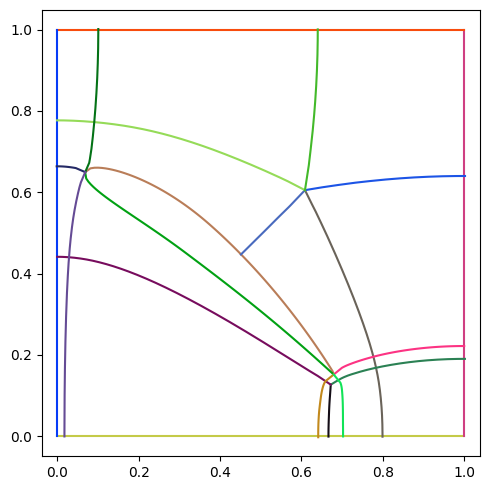

In [9]:
plot_streamlines(streamline.mesh)

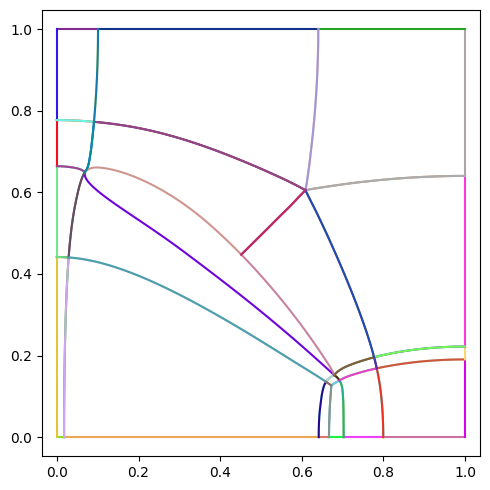

In [15]:
new_sl = []
for key in blocked_mesh.edge_to_streamline.keys():
    new_sl.append(blocked_mesh.edge_to_streamline[key])
blocked_mesh.streamlines = new_sl
plot_streamlines(blocked_meshmesh)

In [10]:
streamlineMerging               = StreamlineMerging(streamline.mesh, verbose=True)
new_streamlines                 = streamlineMerging.new_streamlines


 function pre_processing 


 started function merge_streamlines


 started function search_duplicated_streamlines


 found 0 streamlines to merge



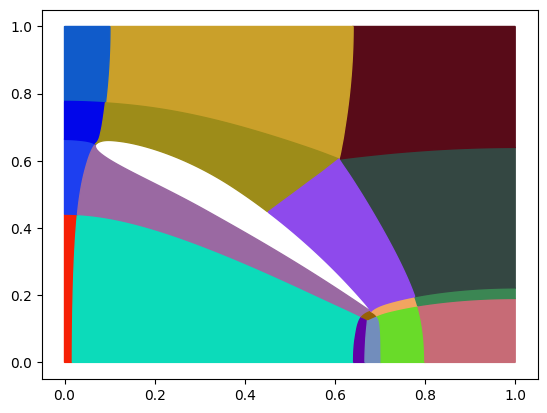

In [16]:
plt_faces(blocked_mesh)

In [17]:
blocked_mesh.faces

tensor([[ 0,  1, 27,  2, 26,  3, 24,  4,  5, 22, 22,  8,  9, 11, 12, 14, 17, 18],
        [ 1,  2, 17,  3, 19,  4, 25,  5,  6, 21,  7,  9, 10, 12, 13, 15, 18, 19],
        [27, 26, 15, 24, 17, 25, 19, 22,  7, 19,  8, 20, 11, 23, 14, 17, 20, 21],
        [16, 27, 16, 26, 27, 24, 26, 25, 22, 25, 21, 21, 20, 20, 23, 23, 23, 20]])

In [42]:
gmsh.initialize()
gmsh.model.add("quad_mesh")
gmsh.model.mesh.setTransfiniteAutomatic([], cornerAngle=2.35, recombine=True)

nodes = quad_mesh.x
faces = quad_mesh.faces
streamline_mapping = quad_mesh.edge_to_streamline_mapping
points = {}
transfinite_divisions = 10  # Set your desired number of divisions

for i, face in enumerate(faces.T):
    curves = []
    for j in range(4):
        edge = (face[j].item(), face[(j+1)%4].item())
        streamline = streamline_mapping[edge]
        
        curve_points = []
        for pt in streamline:
            key = (round(pt[0], 3), round(pt[1], 3))
            if key not in points:
                points[key] = gmsh.model.geo.addPoint(pt[0], pt[1], 0)
            curve_points.append(points[key])
 
        if len(curve_points) == 2:
            curve_id = gmsh.model.geo.addLine(curve_points[0], curve_points[1])
        else:
            curve_id = gmsh.model.geo.addSpline(curve_points)
        
        curves.append(curve_id)
        gmsh.model.geo.mesh.setTransfiniteCurve(curve_id, transfinite_divisions)
    
    loop = gmsh.model.geo.addCurveLoop(curves)
    surf = gmsh.model.geo.addPlaneSurface([loop])
    gmsh.model.geo.mesh.setTransfiniteSurface(surf, "Alternate")
    gmsh.model.geo.mesh.setRecombine(2, surf)

gmsh.model.geo.synchronize()
gmsh.model.mesh.generate(2)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Nurb)
Info    : [ 10%] Meshing curve 2 (Nurb)
Info    : [ 10%] Meshing curve 3 (Nurb)
Info    : [ 20%] Meshing curve 4 (Nurb)
Info    : [ 20%] Meshing curve 5 (Nurb)
Info    : [ 30%] Meshing curve 6 (Nurb)
Info    : [ 30%] Meshing curve 7 (Nurb)
Info    : [ 30%] Meshing curve 8 (Nurb)
Info    : [ 40%] Meshing curve 9 (Nurb)
Info    : [ 40%] Meshing curve 10 (Nurb)
Info    : [ 50%] Meshing curve 11 (Nurb)
Info    : [ 50%] Meshing curve 12 (Nurb)
Info    : [ 60%] Meshing curve 13 (Nurb)
Info    : [ 60%] Meshing curve 14 (Nurb)
Info    : [ 60%] Meshing curve 15 (Nurb)
Info    : [ 70%] Meshing curve 16 (Nurb)
Info    : [ 70%] Meshing curve 17 (Nurb)
Info    : [ 80%] Meshing curve 18 (Nurb)
Info    : [ 80%] Meshing curve 19 (Nurb)
Info    : [ 80%] Meshing curve 20 (Nurb)
Info    : [ 90%] Meshing curve 21 (Nurb)
Info    : [ 90%] Meshing curve 22 (Nurb)
Info    : [100%] Meshing curve 23 (Nurb)
Info    : [100%] Meshing curve 24 (Nurb)
I

In [43]:
def faces_to_edges(faces):
    
    if faces.size()[0] == 3:
            edge_index = torch.cat([
                faces[:2],
                faces[1:],
                faces[::2],
            ], dim=1)
    else:
            assert faces.size()[0] == 4
            edge_index = torch.cat([
                faces[:2],
                faces[1:3],
                faces[2:4],
                faces[::2],
                faces[1::2],
                faces[::3],
            ], dim=1)

    return edge_index


In [35]:
from torch_geometric.utils import to_undirected, remove_isolated_nodes

In [44]:

 1

# gmsh.write("quad_mesh.msh")
# gmsh.finalize()

In [48]:
def plt_mesh(mesh):
    for i,face in enumerate(mesh.faces.T):
        color = np.random.rand(3,)
        nodes = mesh.x[face,:]
        plt.fill(nodes[:,0],nodes[:,1],color=color,alpha=0.5)

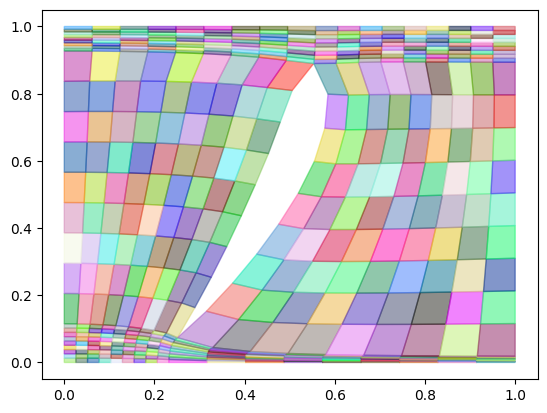

In [49]:
plt_mesh(transfinite_mesh)

In [45]:
transfinite_mesh

Data(x=[588, 3], edge_index=[2, 2916], faces=[4, 486])

In [ ]:
faces = quad_mesh.faces

In [19]:
gmsh.initialize()
gmsh.model.add("quad_mesh")

nodes = quad_mesh.x
faces = quad_mesh.faces
num_edges_each_faces = faces.size(0)
streamline_mapping = quad_mesh.edge_to_streamline_mapping
for i, face in enumerate(faces.T):
    streamlines = []
    for j in range(num_edges_each_faces):
        edge_idx1 =j
        edge_idx2 =(j+1)%num_edges_each_faces

        edge = (face[edge_idx1].item(),face[edge_idx2].item())
        streamline = streamline_mapping[edge]
        for point in streamline:
            key = (round(pt[0], 4), round(pt[1], 4))
            if key not in points:
                points[key] = gmsh.model.geo.addPoint(pt[0], pt[1], 0)
            curve_points.append(points[key])
        if len(curve_points) == 2:
            curves.append(gmsh.model.geo.addLine(curve_points[0], curve_points[1]))
        else:
            curves.append(gmsh.model.geo.addSpline(curve_points))
        
    
    loop = gmsh.model.geo.addCurveLoop(curves)
    surf = gmsh.model.geo.addPlaneSurface([loop])
    gmsh.model.geo.mesh.setTransfiniteSurface(surf)
    gmsh.model.geo.mesh.setRecombine(2, surf)

Error   : Unknown control point 793 in GEO curve 1


Exception: Unknown control point 793 in GEO curve 1